In [4]:
import sys; sys.path.append('scripts')
from transformer import GPTLanguageModel, encode, decode

model = GPTLanguageModel()
model.load_state_dict(torch.load('models/model.pt'))
model.eval()
model.to('mps')

GPTLanguageModel(
  (token_embedding_table): Embedding(65, 384)
  (position_embedding_table): Embedding(256, 384)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-5): 6 x Head(
            (key): Linear(in_features=384, out_features=64, bias=False)
            (query): Linear(in_features=384, out_features=64, bias=False)
            (value): Linear(in_features=384, out_features=64, bias=False)
            (dropout): Dropout(p=0.2, inplace=False)
          )
        )
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (ffwd): FeedFoward(
        (net): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): ReLU()
          (2): Linear(in_features=1536, out_features=384, bias=True)
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (ln1): LayerNorm((384,), eps=1e-05, elementwise_affine=

In [6]:
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chunk = text[-5000:][:257]
ids = encode(chunk)

x = torch.tensor(ids[:-1]).unsqueeze(0).to('mps')
y = torch.tensor(ids[1:]).unsqueeze(0).to('mps')

with torch.no_grad():
    logits, loss = model(x, y)
print(loss.item())

1.542173147201538


In [8]:
cache = {}

def make_hook(layer, head):
    def hook(module, inp, out):
        cache[(layer, head)] = out.detach()
    return hook

handles = []
for layer in range(6):
    for head in range(6):
        h = model.blocks[layer].sa.heads[head].dropout.register_forward_hook(make_hook(layer, head))
        handles.append(h)

with torch.no_grad():
    logits, loss = model(x, y)

for h in handles:
    h.remove()

print(len(cache))
print(cache[(0, 0)].shape)

36
torch.Size([1, 256, 256])


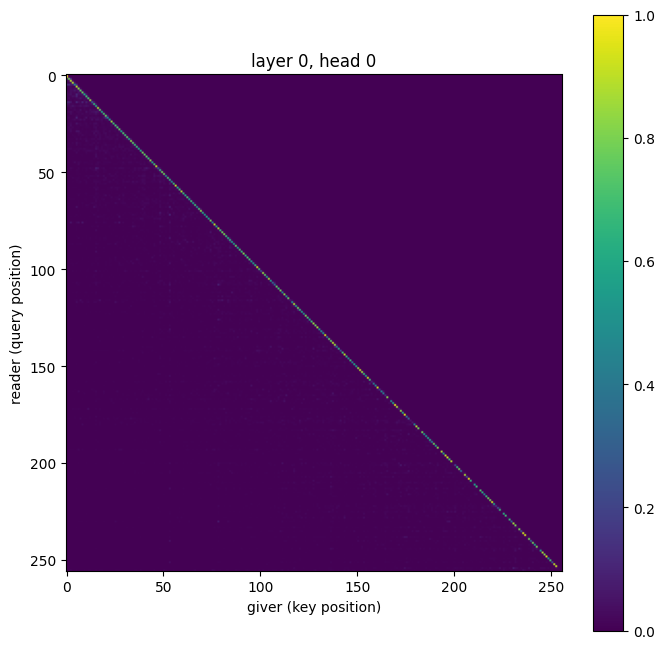

In [9]:
import matplotlib.pyplot as plt

layer, head = 0, 0
wei = cache[(layer, head)][0].cpu()   # (256, 256), off mps for plotting

plt.figure(figsize=(8, 8))
plt.imshow(wei, cmap='viridis')
plt.xlabel('giver (key position)')
plt.ylabel('reader (query position)')
plt.title(f'layer {layer}, head {head}')
plt.colorbar()
plt.show()

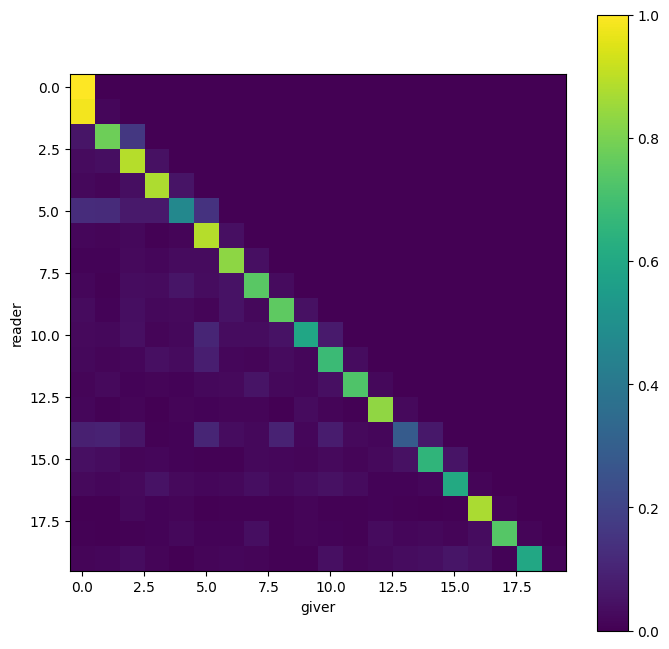

In [10]:
plt.figure(figsize=(8,8))
plt.imshow(wei[:20, :20], cmap='viridis')   # top-left 20×20 corner
plt.xlabel('giver'); plt.ylabel('reader')
plt.colorbar(); plt.show()

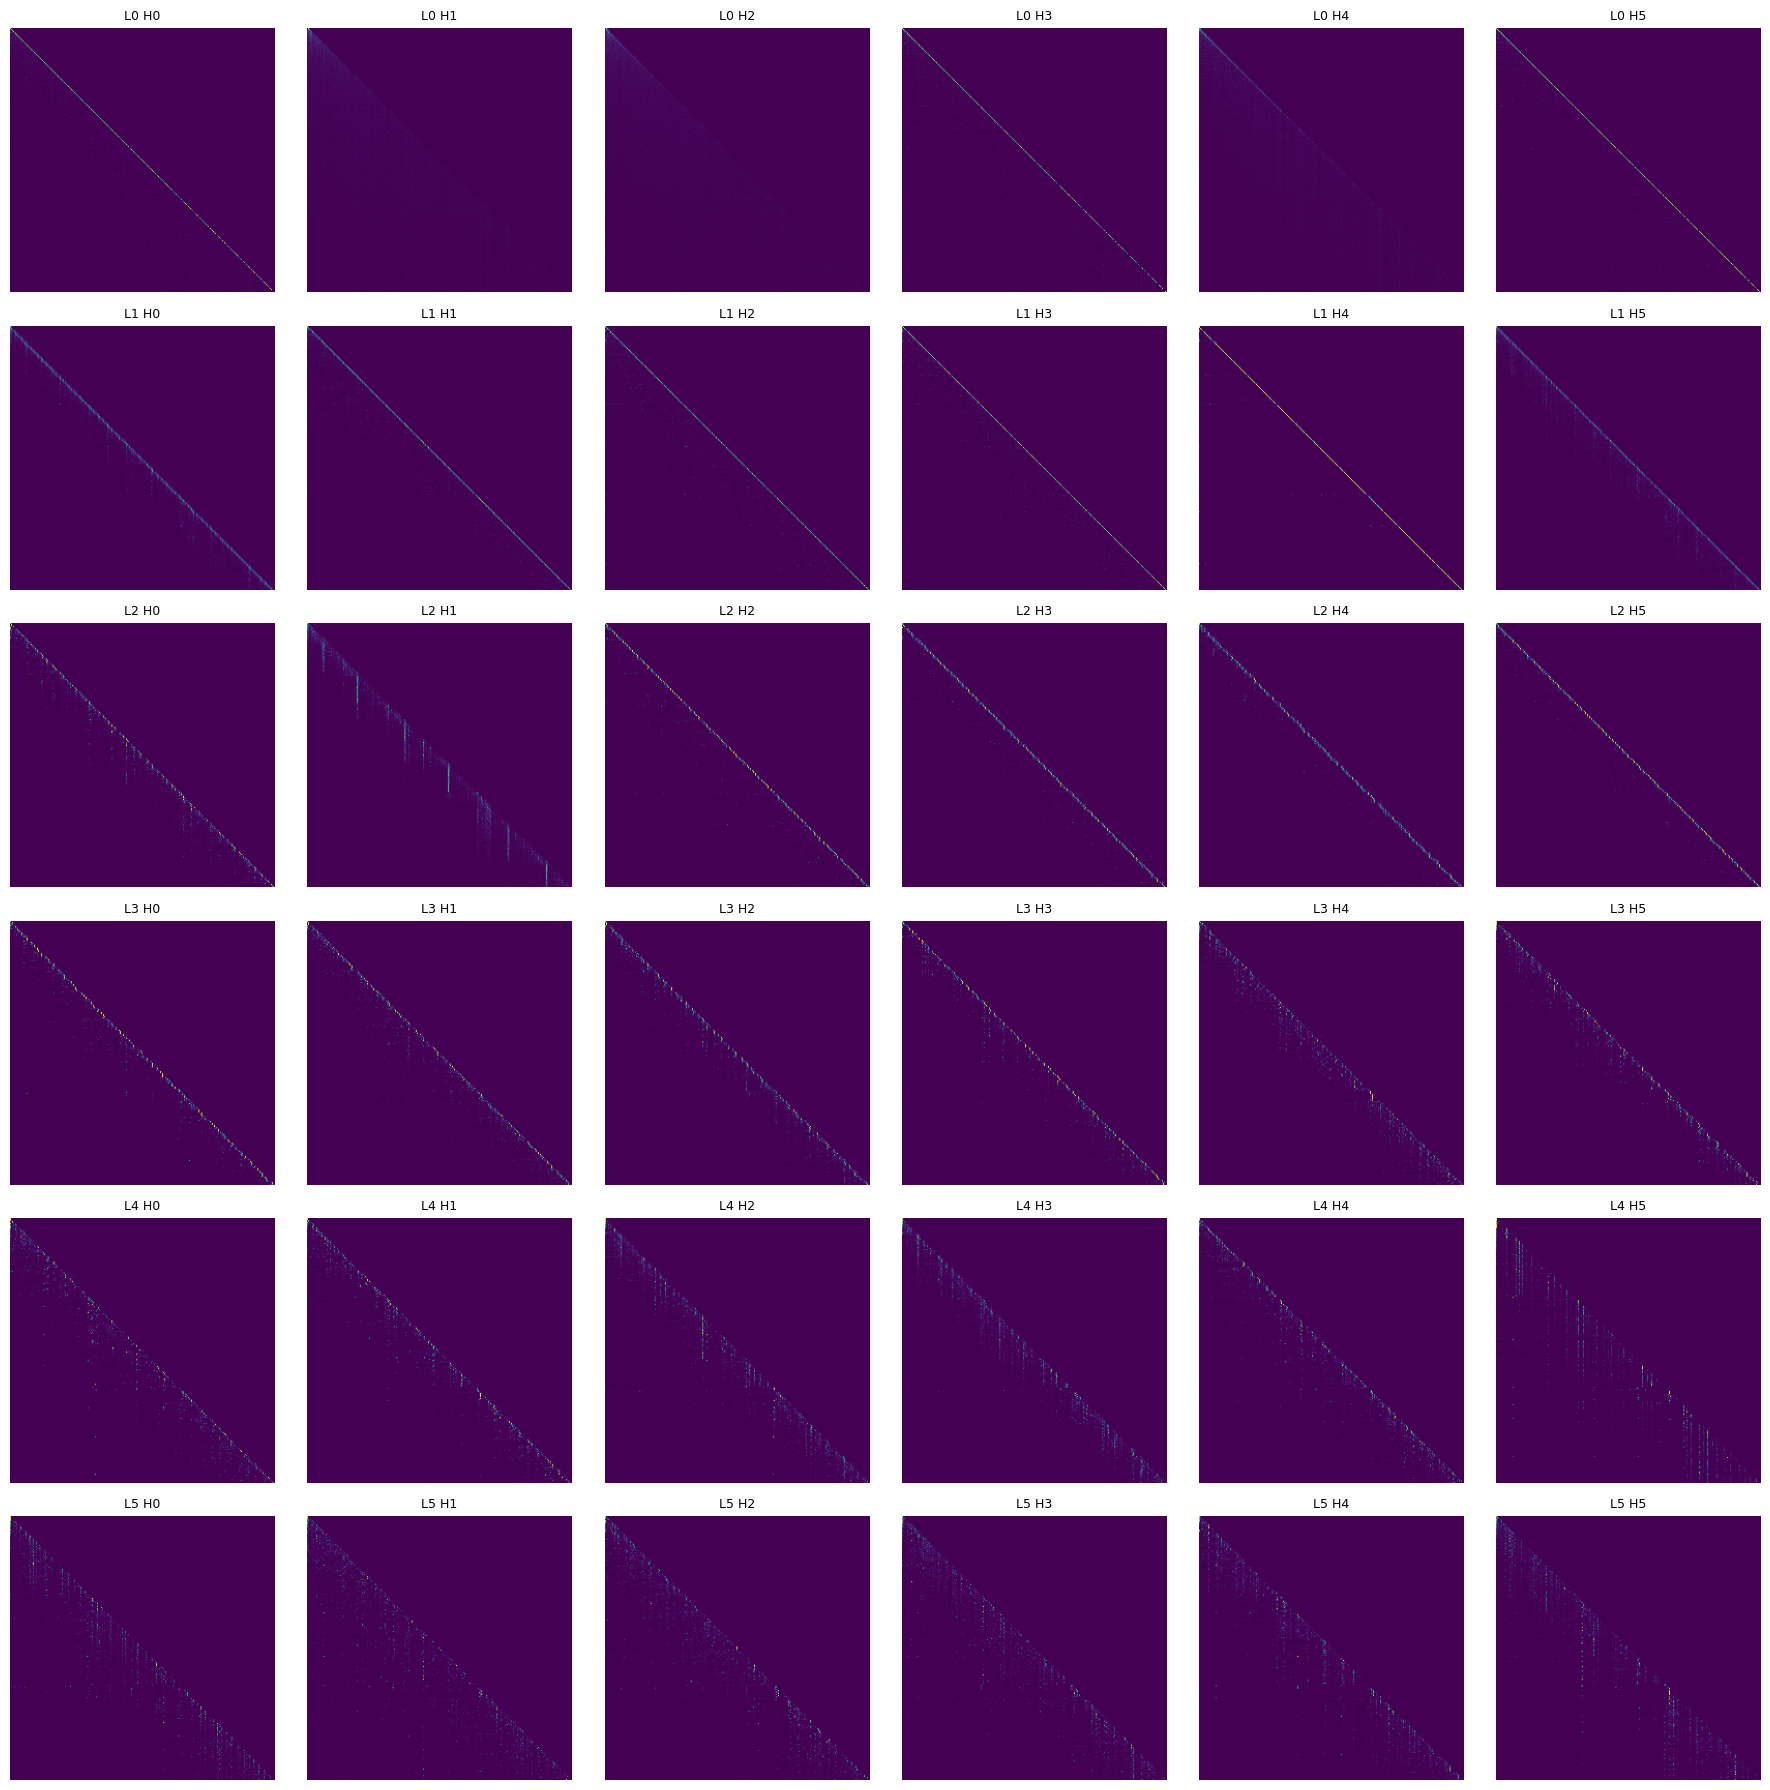

In [11]:
fig, axes = plt.subplots(6, 6, figsize=(18, 18))
for layer in range(6):
    for head in range(6):
        ax = axes[layer, head]
        ax.imshow(cache[(layer, head)][0].cpu(), cmap='viridis')
        ax.set_title(f'L{layer} H{head}', fontsize=9)
        ax.axis('off')
plt.tight_layout(); plt.show()

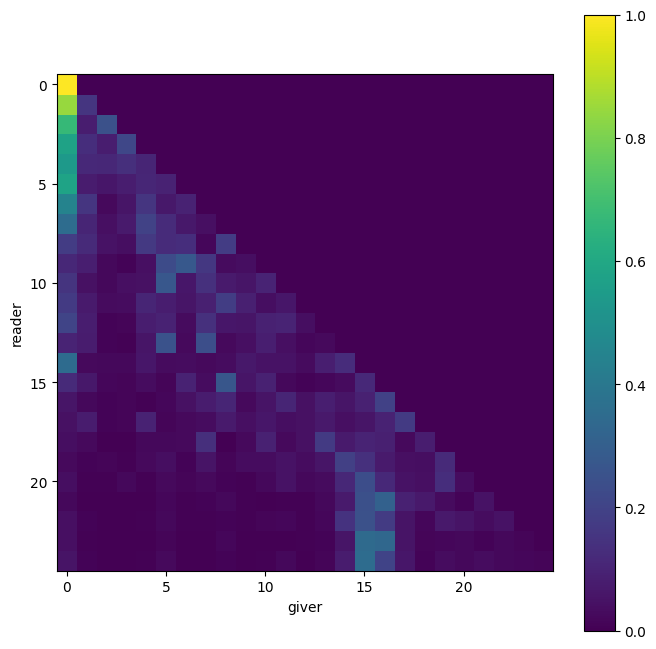

In [12]:
w = cache[(2,1)][0].cpu()
plt.figure(figsize=(8,8))
plt.imshow(w[:25,:25], cmap='viridis')
plt.xlabel('giver'); plt.ylabel('reader'); plt.colorbar(); plt.show()

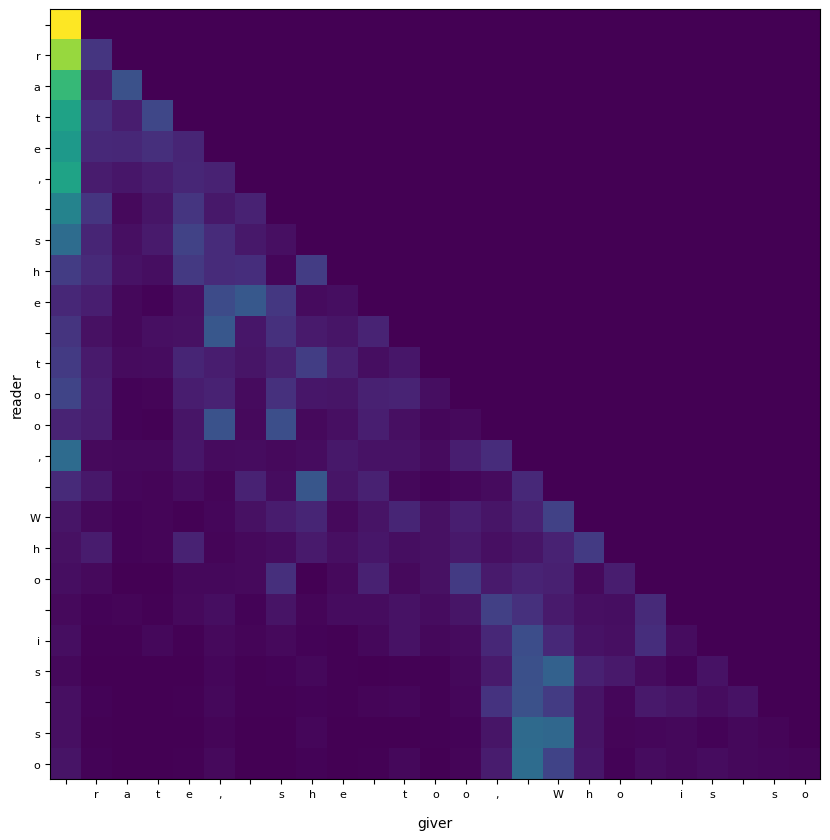

In [13]:
chars_list = list(chunk[:25])   # the 25 chars these positions correspond to

w = cache[(2,1)][0,:25,:25].cpu()
fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(w, cmap='viridis')
ax.set_xticks(range(25)); ax.set_xticklabels(chars_list, fontsize=8)
ax.set_yticks(range(25)); ax.set_yticklabels(chars_list, fontsize=8)
ax.set_xlabel('giver'); ax.set_ylabel('reader')
plt.show()

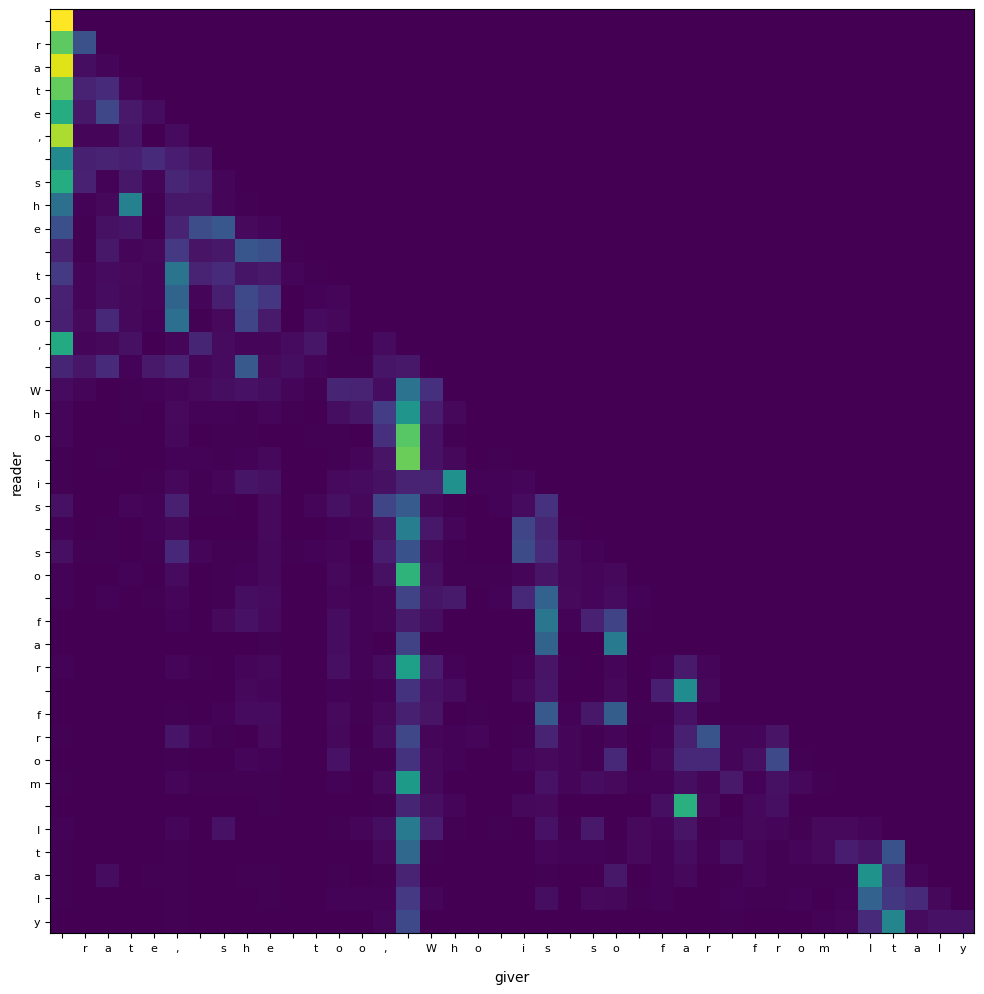

In [14]:
L, H = 4, 3
n = 40                          # wider window — names need room to persist
labels = list(chunk[:n])
w = cache[(L, H)][0, :n, :n].cpu()

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(w, cmap='viridis')
ax.set_xticks(range(n)); ax.set_xticklabels(labels, fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('giver'); ax.set_ylabel('reader')
plt.show()

In [17]:
val_text = text[int(0.9*len(text)):]

import re
# every all-caps word of length >=4 (Shakespeare speaker labels / shouted names)
words = re.findall(r'[A-Z]{4,}', val_text)

from collections import Counter
common = Counter(words).most_common(10)
print("most repeated all-caps tokens:", common)

most repeated all-caps tokens: [('PETRUCHIO', 137), ('KATHARINA', 71), ('TRANIO', 64), ('PROSPERO', 63), ('BAPTISTA', 62), ('GRUMIO', 46), ('HORTENSIO', 44), ('SEBASTIAN', 42), ('LUCENTIO', 41), ('ANTONIO', 38)]


In [18]:
hits = [m.start() for m in re.finditer('PETRUCHIO', val_text)]
# find the first pair within ~200 chars of each other
for a, b in zip(hits, hits[1:]):
    if b - a < 200:
        print("first occurrence at", a, "second at", b, "gap", b - a)
        start = max(0, a - 20)            # a little lead-in before the first name
        break

chunk = val_text[start:start+257]         # 257-char window containing both PETRUCHIOs
print(repr(chunk))

first occurrence at 112 second at 309 gap 197
"ve you, gentlemen!\n\nPETRUCHIO:\nAnd you, good sir! Pray, have you not a daughter\nCall'd Katharina, fair and virtuous?\n\nBAPTISTA:\nI have a daughter, sir, called Katharina.\n\nGREMIO:\nYou are too blunt: go to it orderly.\n\nPETRUCHIO:\nYou wrong me, Signior Gremio:"


In [19]:
# rebuild x from the new chunk
ids = encode(chunk)
x = torch.tensor(ids[:-1]).unsqueeze(0).to('mps')
y = torch.tensor(ids[1:]).unsqueeze(0).to('mps')

# re-run forward with the 36 hooks still attached? No — they were removed. Re-attach.
cache = {}
handles = []
for layer in range(6):
    for head in range(6):
        h = model.blocks[layer].sa.heads[head].dropout.register_forward_hook(make_hook(layer, head))
        handles.append(h)

with torch.no_grad():
    logits, loss = model(x, y)

for h in handles:
    h.remove()

print(len(cache), loss.item())

36 1.036675214767456


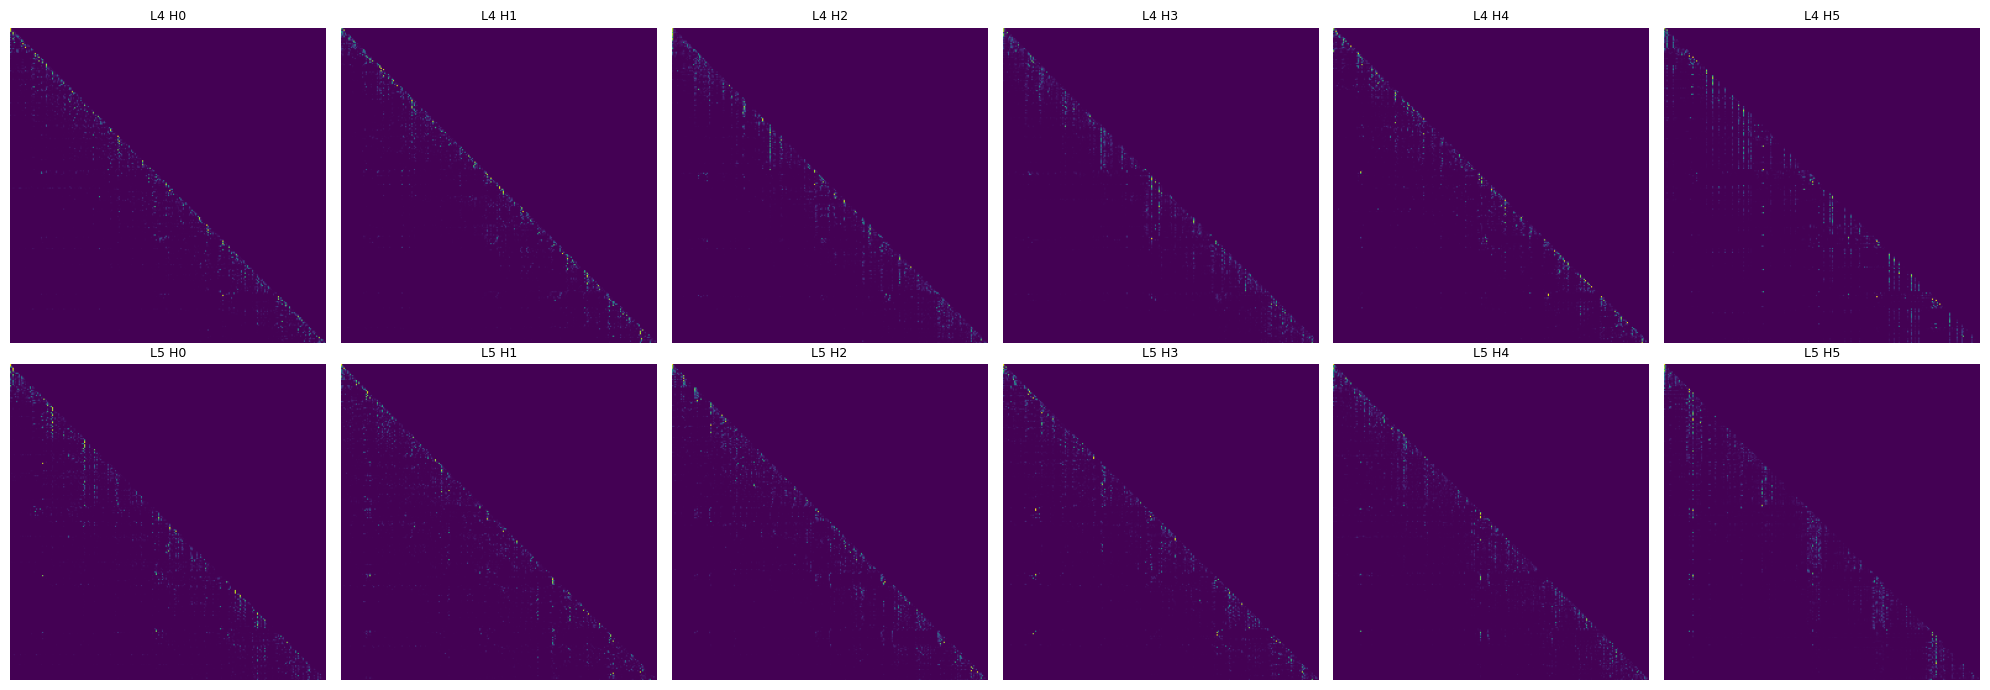

In [20]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for i, layer in enumerate([4, 5]):
    for head in range(6):
        ax = axes[i, head]
        ax.imshow(cache[(layer, head)][0].cpu(), cmap='viridis')
        ax.set_title(f'L{layer} H{head}', fontsize=9)
        ax.axis('off')
plt.tight_layout(); plt.show()

In [21]:
import torch

seq_len = 50
# random token ids, repeated twice -> shape (1, 2*seq_len)
rand = torch.randint(0, 65, (1, seq_len))
rep = torch.cat([rand, rand], dim=1).to('mps')   # (1, 100)

# capture attention on this repeated sequence
cache = {}
handles = []
for layer in range(6):
    for head in range(6):
        h = model.blocks[layer].sa.heads[head].dropout.register_forward_hook(make_hook(layer, head))
        handles.append(h)
with torch.no_grad():
    model(rep)          # no targets needed, we only want the attention
for h in handles:
    h.remove()

# induction score per head
scores = {}
for layer in range(6):
    for head in range(6):
        wei = cache[(layer, head)][0]            # (100, 100)
        total = 0.0
        for i in range(seq_len, 2*seq_len):      # readers in the SECOND half
            target = i - seq_len + 1             # the induction target position
            total += wei[i, target].item()
        scores[(layer, head)] = total / seq_len

for k in sorted(scores, key=scores.get, reverse=True)[:8]:
    print(k, round(scores[k], 3))

(5, 2) 0.017
(0, 2) 0.014
(0, 1) 0.012
(0, 4) 0.009
(5, 3) 0.007
(5, 0) 0.007
(4, 5) 0.006
(5, 4) 0.006


In [22]:
prev_scores = {}
for layer in range(6):
    for head in range(6):
        wei = cache[(layer, head)][0]            # (100, 100)
        total = 0.0
        for i in range(1, 2*seq_len):            # every reader except position 0
            total += wei[i, i-1].item()          # attention exactly one back
        prev_scores[(layer, head)] = total / (2*seq_len - 1)

for k in sorted(prev_scores, key=prev_scores.get, reverse=True)[:8]:
    print(k, round(prev_scores[k], 3))

(0, 5) 0.682
(1, 2) 0.636
(1, 3) 0.631
(0, 0) 0.63
(0, 3) 0.608
(1, 1) 0.572
(2, 5) 0.31
(2, 2) 0.308


In [23]:
# a name that does NOT exist in Shakespeare
fake = "ZYXQWOR"
prompt = f"\n{fake}:\nHello there, good sir.\n\n{fake}:\n"
ids = encode(prompt)
x = torch.tensor(ids).unsqueeze(0).to('mps')

# generate 8 chars and see if it reproduces the fake name
with torch.no_grad():
    out = model.generate(x, max_new_tokens=8)
print(repr(decode(out[0].tolist())[-15:]))

'XQWOR:\nCome, my'
